In [1]:
from google.colab import drive
import os
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def count_total_images(directory):
    total_images = 0
    for root, _, files in os.walk(directory):
        total_images += len([f for f in files if f.lower().endswith(('jpg', 'jpeg', 'png', 'bmp', 'gif'))])
    return total_images

In [4]:
fruits_and_veggies_train = "/content/drive/My Drive/DL_Dataset/Train"
fruits_and_veggies_test = "/content/drive/My Drive/DL_Dataset/Test"
dataset_path = "/content/drive/My Drive/DL_Dataset"

train_count = count_total_images(fruits_and_veggies_train)
test_count = count_total_images(fruits_and_veggies_test)
total_images = count_total_images(dataset_path)

print(f"Training set contains {train_count} images")
print(f"Test set contains {test_count} images")
print(f"Total number of images in the dataset: {total_images}")

Training set contains 23629 images
Test set contains 6738 images
Total number of images in the dataset: 30367


In [5]:
classifications = ['freshapples',  'rottenapples'] #sorted(os.listdir(fruits_and_veggies_train))
print( len(classifications), classifications)

2 ['freshapples', 'rottenapples']


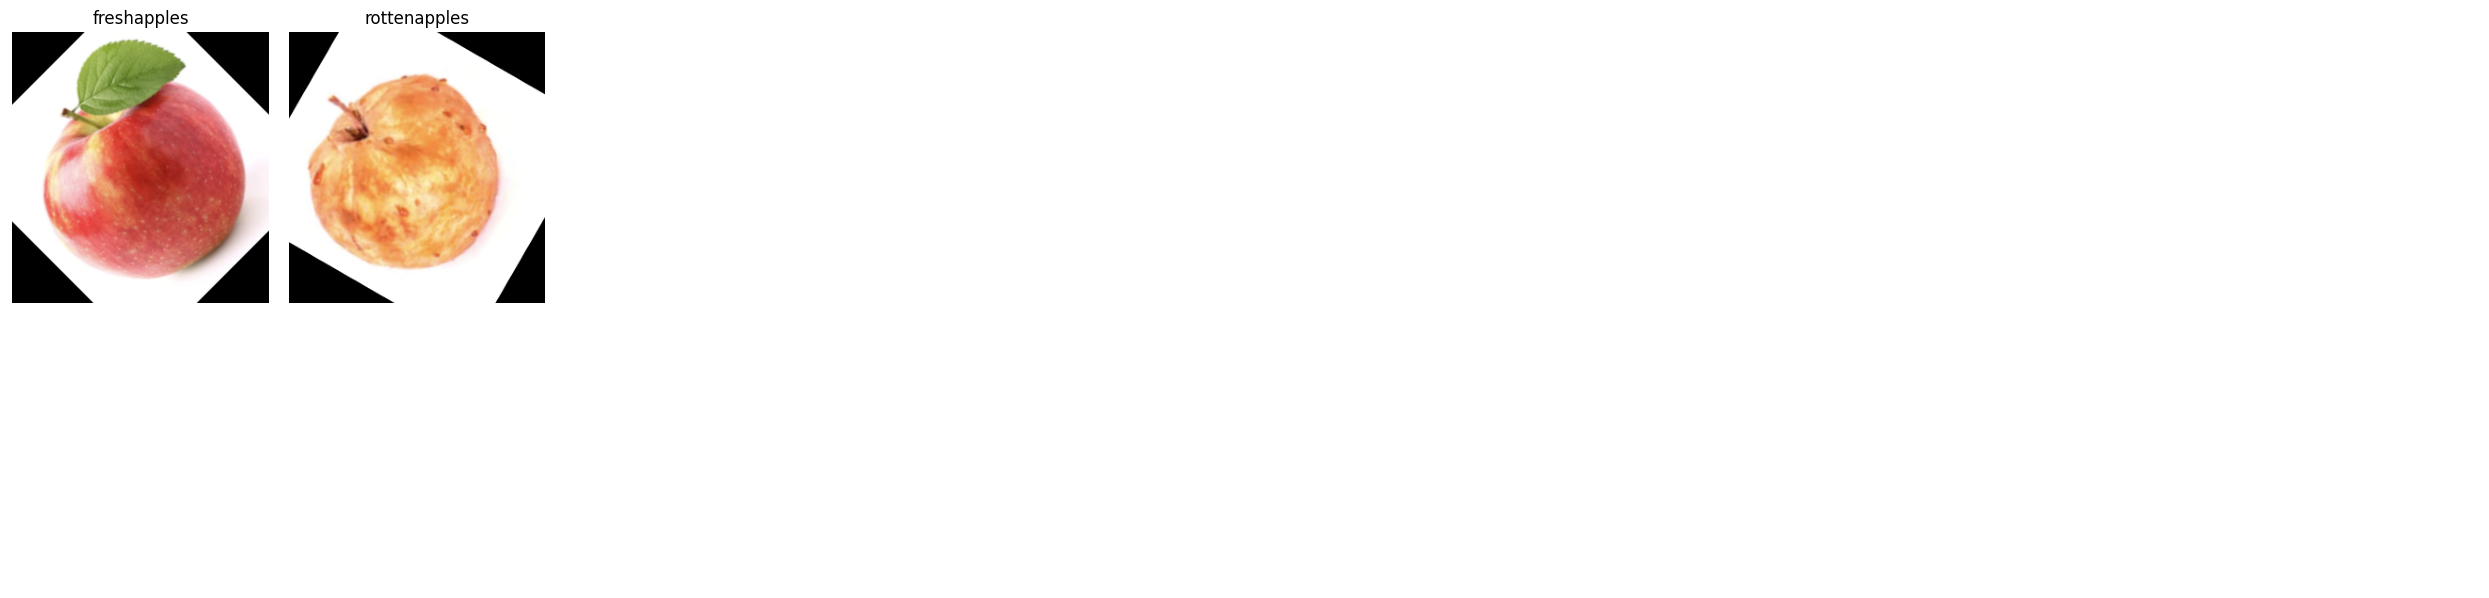

In [6]:
num_classes = len(classifications)
rows, cols = 2, 9  # 2x9 grid
fig, axes = plt.subplots(rows, cols, figsize=(25, 6))

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot one exemplar from each class
for i, class_name in enumerate(classifications):
    class_path = os.path.join(fruits_and_veggies_train, class_name)
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

    if image_files:  # Ensure the class folder is not empty
        img_path = os.path.join(class_path, image_files[0])  # Select first image
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(class_name)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [7]:
input_shape = (224, 224, 3)
TARGET_SIZE = input_shape[:2]
EPOCHS = 7
BATCH_SIZE = 4

In [8]:
mobilenet_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
mobilenet_model.trainable = True

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
layers = [(layer, layer.name, layer.trainable) for layer in mobilenet_model.layers]
pd.DataFrame(layers, columns=['Layer Type', 'Layer Name', 'Layer Trainable'])

,Layer Type,Layer Name,Layer Trainable
0,"<InputLayer name=input_layer, built=True>",input_layer,True
1,"<Conv2D name=Conv1, built=True>",Conv1,True
2,"<BatchNormalization name=bn_Conv1, built=True>",bn_Conv1,True
3,"<ReLU name=Conv1_relu, built=True>",Conv1_relu,True
4,"<DepthwiseConv2D name=expanded_conv_depthwise,...",expanded_conv_depthwise,True
...,...,...,...
149,"<Conv2D name=block_16_project, built=True>",block_16_project,True
150,"<BatchNormalization name=block_16_project_BN, ...",block_16_project_BN,True
151,"<Conv2D name=Conv_1, built=True>",Conv_1,True
152,"<BatchNormalization name=Conv_1_bn, built=True>",Conv_1_bn,True


In [10]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   zoom_range=0.3,
                                   rotation_range=50,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')
val_datagen = ImageDataGenerator(rescale=1./255)


In [11]:

train_generator = train_datagen.flow_from_directory(fruits_and_veggies_train,
                                                 target_size = TARGET_SIZE,
                                                 batch_size = BATCH_SIZE,
                                                 class_mode = 'categorical',
                                                 classes=classifications)

val_generator = val_datagen.flow_from_directory(fruits_and_veggies_test,
                                                target_size = TARGET_SIZE,
                                                batch_size = BATCH_SIZE,
                                                class_mode = 'categorical',
                                                classes=classifications,)

Found 5672 images belonging to 2 classes.
Found 1779 images belonging to 2 classes.


In [12]:
model = Sequential()
model.add(mobilenet_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(units=2, activation='softmax'))

model.compile(loss='categorical_crossentropy',optimizer=optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, amsgrad=False),
              metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,226,434 (8.49 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [13]:
early_stopping = EarlyStopping(monitor='val_loss',
                               min_delta=0,
                               patience=1,
                               verbose=0,
                               mode='auto')

history = model.fit(train_generator,
                    steps_per_epoch=train_generator.n // BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=val_generator,
                    validation_steps=val_generator.n // BATCH_SIZE,
                    verbose=1,
                    callbacks=[early_stopping])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/7
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 3170s 2s/step - accuracy: 0.8732 - loss: 0.2864 - val_accuracy: 0.9724 - val_loss: 0.0748
Epoch 2/7
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 1111s 779ms/step - accuracy: 0.9450 - loss: 0.1300 - val_accuracy: 0.9983 - val_loss: 0.0076
Epoch 3/7
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 1153s 773ms/step - accuracy: 0.9851 - loss: 0.0393 - val_accuracy: 0.9977 - val_loss: 0.0074
Epoch 4/7
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 1102s 773ms/step - accuracy: 0.9860 - loss: 0.0421 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 5/7
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 1101s 776ms/step - accuracy: 0.9898 - loss: 0.0297 - val_accuracy: 0.9932 - val_loss: 0.0169


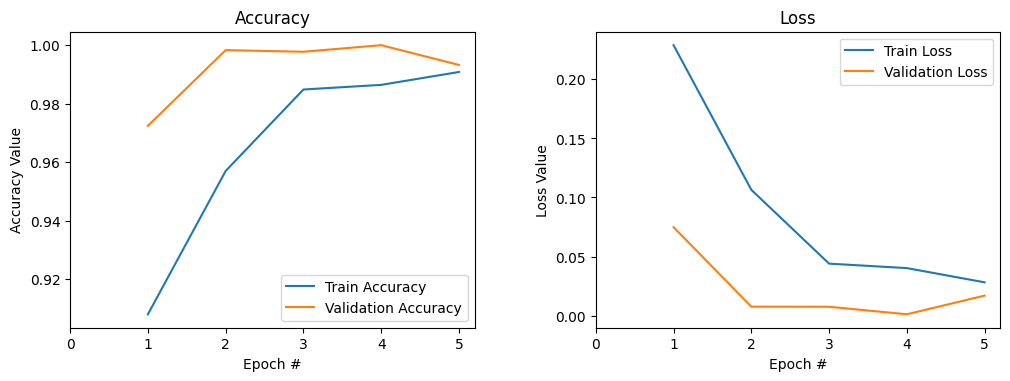

In [14]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
f.subplots_adjust(top=0.85, wspace=0.3)

epoch_list = list(range(1,len(history.history['loss'])+1))
ax1.plot(epoch_list, history.history['accuracy'], label='Train Accuracy')
ax1.plot(epoch_list, history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xticks(np.arange(0, len(history.history['loss'])+1, 1))
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch #')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

ax2.plot(epoch_list, history.history['loss'], label='Train Loss')
ax2.plot(epoch_list, history.history['val_loss'], label='Validation Loss')
ax2.set_xticks(np.arange(0, len(history.history['loss'])+1, 1))
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch #')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


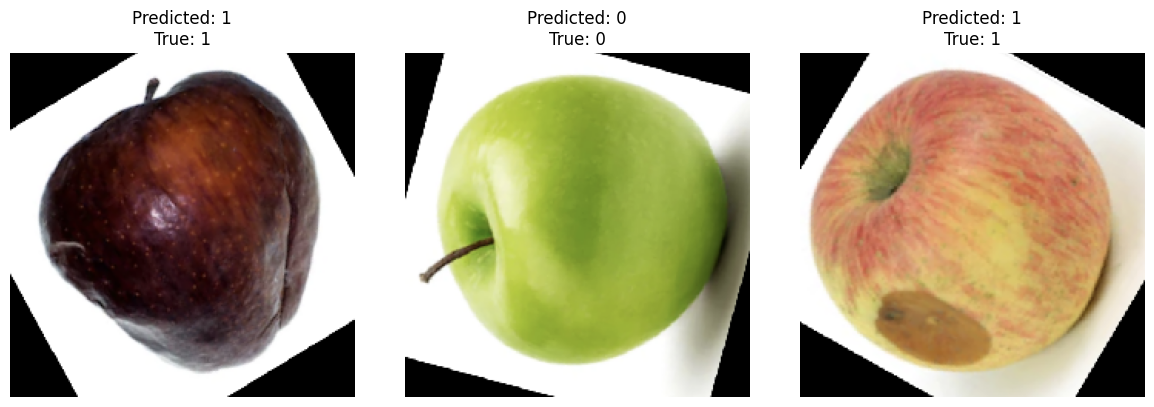

In [18]:
# Get 3 samples from the validation generator
val_samples = next(val_generator)

images, labels = val_samples[0], val_samples[1]  # images and labels from the batch

# Predict 3 samples
predictions = model.predict(images[:3])  # Take the first 3 images from the batch

# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=1)

# Plot 3 images
plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Predicted: {predicted_classes[i]}\nTrue: {np.argmax(labels[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()
